In [1]:
import os
import ot
import gc
import k3d
import torch
import trimesh
import warnings
from tqdm import *
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp
import matplotlib.cm as cm
from anndata import AnnData
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from numpy.random import RandomState
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from sklearn.metrics import jaccard_score
from scipy.stats import fisher_exact, norm
from sklearn.neighbors import NearestNeighbors
from typing import Literal, Optional, Tuple, Union
from matplotlib.colors import ListedColormap, rgb2hex
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.font_manager import fontManager, FontProperties
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import marsilea as ma

In [8]:
adata = sc.read_h5ad('/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_train/rapids_analysis/merfish_mouseBrain_concat_embeddings.h5ad')
adata

AnnData object with n_obs × n_vars = 7743543 × 0
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', 'slice_idx', 'source_file', 'source_stem', 'cell_leiden', 'niche_leiden'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'source_var_name', 'mean', 'std'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'X_umap_cell', 'X_umap_niche', 'ccf', 'cell_embeddi

In [ ]:
cell_leiden_colormap

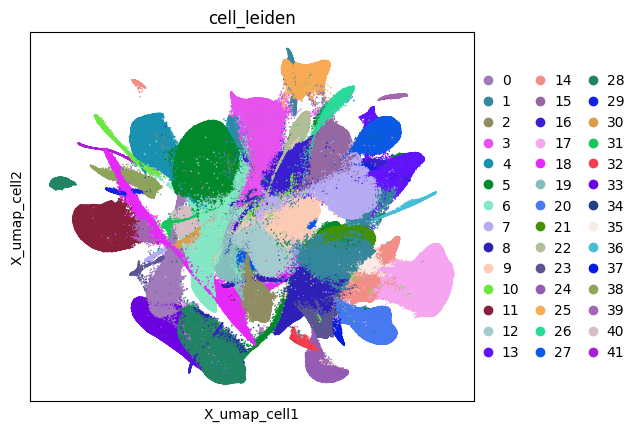

In [10]:
plot = sc.pl.embedding(
        adata, basis="X_umap_cell", color='cell_leiden',
        show=False, s=5, palette = cell_leiden_colormap, 
    )
plot.set_aspect('equal')
plt.show()

In [ ]:
cell_type_colormap

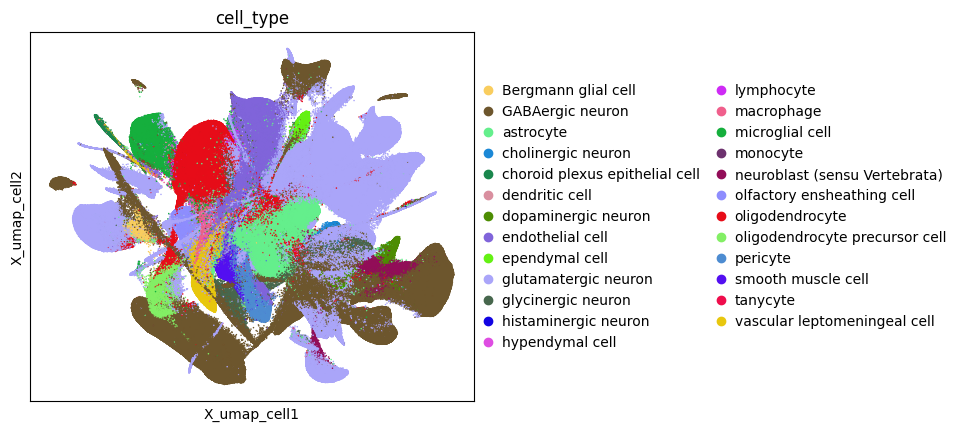

In [11]:
plot = sc.pl.embedding(
        adata, basis="X_umap_cell", color='cell_type',
        show=False, s=5, palette = cell_type_colormap, 
    )
plot.set_aspect('equal')
plt.show()

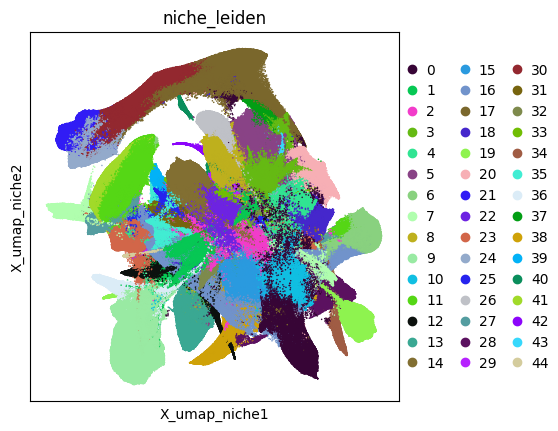

In [12]:
plot = sc.pl.embedding(
        adata, basis="X_umap_niche", color='niche_leiden',
        show=False, s=5, palette = niche_leiden_colormap, 
    )
plot.set_aspect('equal')
plt.show()

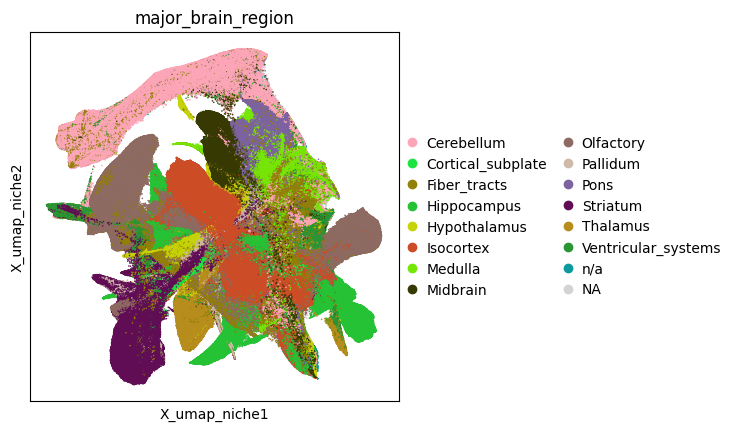

In [13]:
plot = sc.pl.embedding(
        adata, basis="X_umap_niche", color='major_brain_region',
        show=False, s=5, palette = major_brain_region_colormap, 
    )
plot.set_aspect('equal')
plt.show()

In [67]:
adata_temp = adata[adata.obs['brain_section_label'] ==   'C57BL6J-1.053'].copy()
adata_temp

AnnData object with n_obs × n_vars = 33836 × 0
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', 'slice_idx', 'source_file', 'source_stem', 'cell_leiden', 'niche_leiden'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'source_var_name', 'mean', 'std'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'ccf', 'cell_embedding', 'niche_embedding'

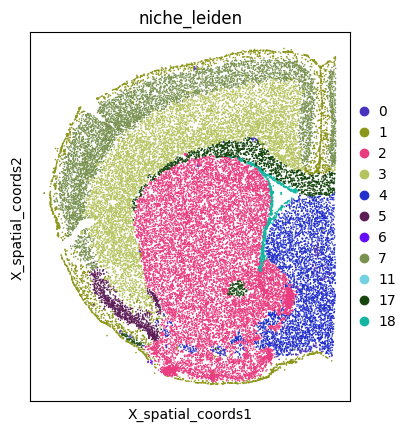

In [68]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='niche_leiden',
        show=False, s=5, palette = niche_leiden_colormap, 
    )
plot.set_aspect('equal')
plt.show()

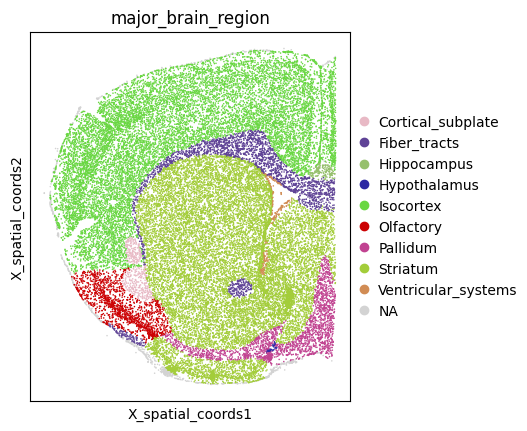

In [69]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='major_brain_region',
        show=False, s=5, palette = major_brain_region_colormap, 
    )
plot.set_aspect('equal')
plt.show()

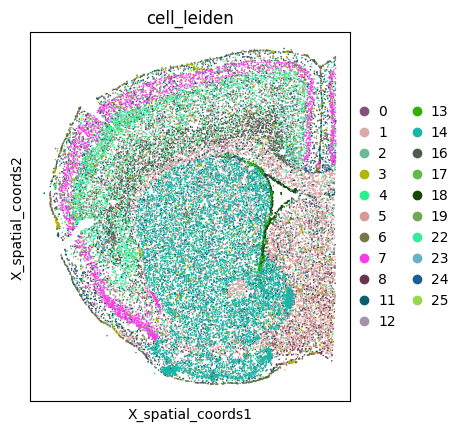

In [70]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='cell_leiden',
        show=False, s=5, palette = cell_leiden_colormap, 
    )
plot.set_aspect('equal')
plt.show()

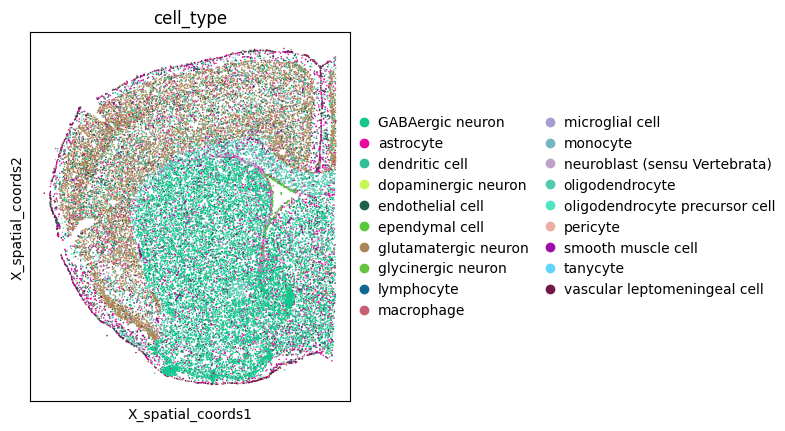

In [71]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='cell_type',
        show=False, s=5, palette = cell_type_colormap, 
    )
plot.set_aspect('equal')
plt.show()

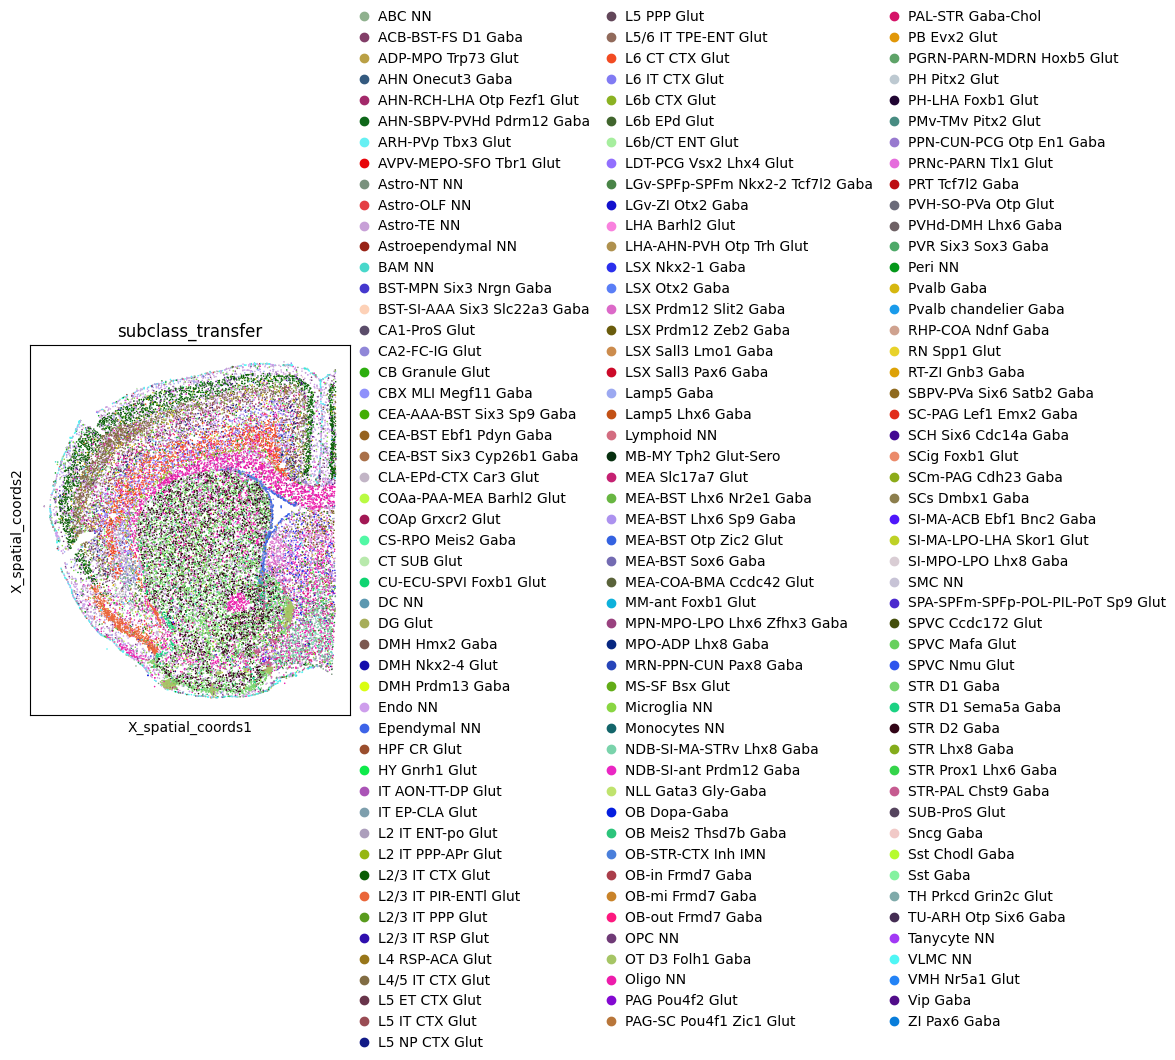

In [72]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='subclass_transfer',
        show=False, s=5, palette = subclass_transfer_colormap, 
    )
plot.set_aspect('equal')
plt.show()

In [9]:
import numpy as np
from matplotlib.colors import ListedColormap, rgb2hex
dmt_leiden_anno = list(set(adata.obs['cell_leiden']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
cell_leiden_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

dmt_leiden_anno = list(set(adata.obs['subclass_transfer']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
subclass_transfer_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

dmt_leiden_anno = list(set(adata.obs['cell_type']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
cell_type_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

dmt_leiden_anno = list(set(adata.obs['major_brain_region']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
major_brain_region_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

dmt_leiden_anno = list(set(adata.obs['major_brain_region']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
major_brain_region_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

dmt_leiden_anno = list(set(adata.obs['niche_leiden']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
niche_leiden_colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon

confusion_matrix = pd.crosstab(
    adata.obs['major_brain_region'], 
    adata.obs['niche_leiden'], 
    normalize='index'
)

In [47]:
set(adata.obs['major_brain_region'])

{'Cerebellum',
 'Cortical_subplate',
 'Fiber_tracts',
 'Hippocampus',
 'Hypothalamus',
 'Isocortex',
 'Medulla',
 'Midbrain',
 'Olfactory',
 'Pallidum',
 'Pons',
 'Striatum',
 'Thalamus',
 'Ventricular_systems',
 'n/a',
 nan}

In [48]:
cell_subclass_order = ['Cerebellum',
 'Cortical_subplate',
 'Fiber_tracts',
 'Hippocampus',
 'Hypothalamus',
 'Isocortex',
 'Medulla',
 'Midbrain',
 'Olfactory',
 'Pallidum',
 'Pons',
 'Striatum',
 'Thalamus',
 'Ventricular_systems']
cell_leiden_order = ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21',
 '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '5', '6', '7', '8', '9']
confusion_matrix = confusion_matrix.loc[cell_subclass_order]
confusion_matrix = confusion_matrix[cell_leiden_order]

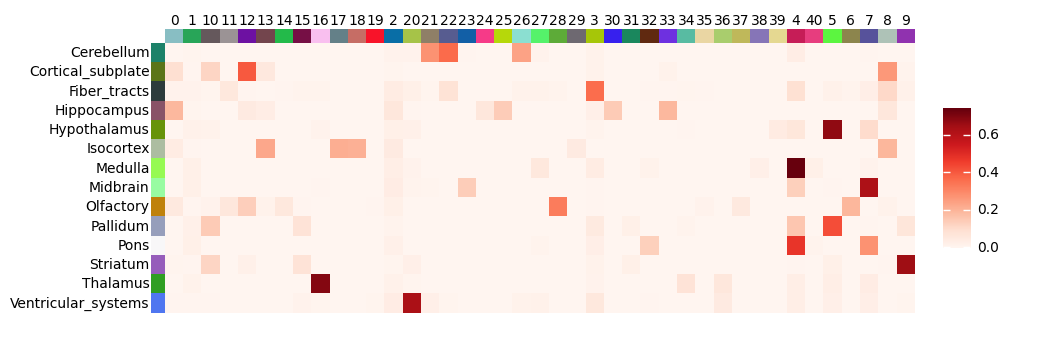

In [56]:
gene_profile = ma.Heatmap(
        confusion_matrix,
        height=2.7,
        width=7.5,
        cmap="Reds",
    )

gene_profile.group_rows(cell_subclass_order, order=cell_subclass_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(cell_subclass_order))], 
        padding=0, 
        fill_colors=[major_brain_region_colormap[i] for i in cell_subclass_order], 
        borderwidth=0
    ),
    pad=0.001
)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=cell_subclass_order,
        padding=0.2,
        fill_colors=None,
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)


gene_profile.group_cols(cell_leiden_order, order=cell_leiden_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(cell_leiden_order))], 
        padding=0, 
        fill_colors = [niche_leiden_colormap[i] for i in cell_leiden_order], 
        borderwidth = 0),
    pad=0.001)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts=cell_leiden_order,
        padding=0.2,
        fill_colors=None, 
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()


# plt.savefig("confusion_matrix.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()

In [70]:
confusion_matrix = pd.crosstab(
    adata.obs['main_region'], 
    adata.obs['niche_leiden'], 
    normalize='index'
)

In [80]:
main_region_order = ['Olfactory areas', 'CTXsp', 'Isocortex',   'Hippocampal formation',  'Hypothalamus',  'Thalamus','Medulla', 'Midbrain',  'Pons',  'Cerebellum', 'Cerebral nuclei',  'Ventricular systems', 'fiber tracts']
niche_leiden_order = [ '4',  '1',  '10', '18', '21', '6','15',  '2',  '3', '11', '12', '13', '14',  '16', '17',  '19', '20',  '22', '23', '24', '5', '7', '8', '9', '0',]
confusion_matrix = confusion_matrix.loc[main_region_order]
confusion_matrix = confusion_matrix[niche_leiden_order]

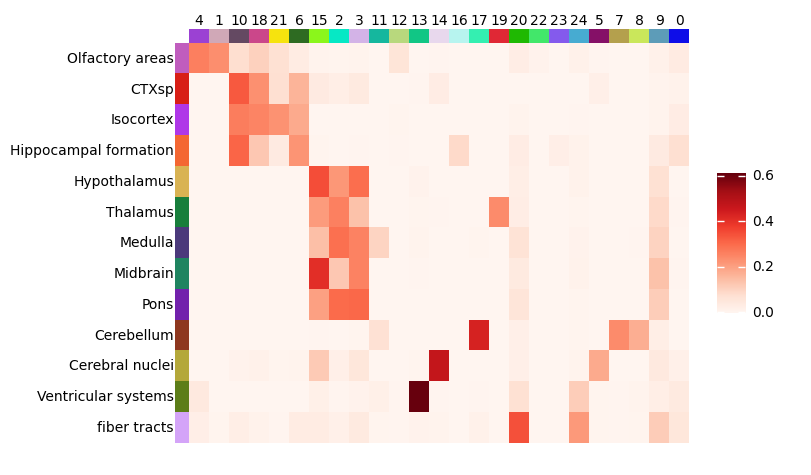

In [81]:
gene_profile = ma.Heatmap(
        confusion_matrix,
        height=4,
        width=5,
        cmap="Reds",
    )

gene_profile.group_rows(main_region_order, order=main_region_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(main_region_order))], 
        padding=0, 
        fill_colors=[main_region_colormap[i] for i in main_region_order], 
        borderwidth=0
    ),
    pad=0.001
)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=main_region_order,
        padding=0.2,
        fill_colors=None,
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)


gene_profile.group_cols(niche_leiden_order, order=niche_leiden_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(niche_leiden_order))], 
        padding=0, 
        fill_colors = [niche_leiden_colormap[i] for i in niche_leiden_order], 
        borderwidth = 0),
    pad=0.001)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts=niche_leiden_order,
        padding=0.2,
        fill_colors=None, 
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()


# plt.savefig("confusion_matrix.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()